# Logistics Delivery Performance Analytics Project
This project analyzes delivery logistics operations to identify drivers of delays, evaluate partner performance, and improve operational efficiency.

### Dataset Description
The dataset `Delivery_Logistics.csv` contains 25,000 rows of delivery logs with the following details:
- `delivery_id`: Unique delivery identifier.
- `delivery_partner`: The 3PL partner carrying the package (e.g., Delhivery, Xpressbees, Shadowfax, DHL, Ecom Express, Bluedart, Ekart, Amazon Logistics, DTDC).
- `package_type`: Category of items being shipped.
- `vehicle_type`: Vehicle used for the delivery.
- `delivery_mode`: Shipping speed class (Same Day, Express, Two Day, Standard).
- `region`: Geographical region of delivery.
- `weather_condition`: Atmospheric conditions during transit.
- `distance_km`: Trip distance in kilometers.
- `package_weight_kg`: Physical weight of the package.
- `delivery_time_hours`: Actual transit time in hours.
- `expected_time_hours`: Committed/Promised transit time in hours.
- `delayed`: Indication of whether actual delivery time exceeded expected time.
- `delivery_status`: Outcome of the order (Delivered, Cancelled, Returned).
- `delivery_rating`: Customer satisfaction rating (1-5 stars).
- `delivery_cost`: Cost of delivery in INR.



## 2. Imports & Data Loading
We load required packages and our custom loader class `DataLoader` which cleans the numeric fields and recalculates delay flags.



In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Add src to python path to load custom scripts
sys.path.append(os.path.abspath('../src'))
from data_loader import DataLoader
from analysis import Analysis
from visualizations import Visualizer

# Enable inline plotting
%matplotlib inline

# Load cleaned data
csv_path = os.path.abspath('../data/Delivery_Logistics.csv')
loader = DataLoader(csv_path)
df = loader.load_data()
analysis = Analysis(df)



Loading data from D:\Projects2\ds-project\delivery_logistics_project\data\Delivery_Logistics.csv...
Data loading and cleaning completed. Loaded 25000 rows.


## 3. Dataset Overview
Here we check the dimensions, datatypes, summary statistics, and missing value distribution of the dataset.



In [2]:
# Display first 5 rows
df.head()


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost,delay_gap_hours
0,100000.0,xpressbees,electronics,three wheeler,two day,south,rainy,74.07,5.57,50.60,38.66,yes,delivered,2,319.41,11.94
1,100001.0,dtdc,cosmetics,three wheeler,standard,south,cold,296.69,40.57,19.75,12.23,yes,delivered,4,1010.44,7.52
2,100002.0,xpressbees,books,bike,two day,east,stormy,135.94,2.65,43.95,28.54,yes,delivered,3,488.03,15.41
3,100003.0,bluedart,cosmetics,three wheeler,same day,north,windy,117.81,14.82,2.00,2.80,no,delivered,5,683.93,-0.80
4,100004.0,bluedart,furniture,van,two day,north,stormy,319.31,26.94,26.62,20.81,yes,delivered,2,996.67,5.81


In [3]:
# Check column data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  float64
 10  expected_time_hours  25000 non-null  float64
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
 15  delay_gap_hours      25000 non-null 

In [4]:
# Get descriptive statistics
df.describe(include='all')


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost,delay_gap_hours
count,25000.000000,25000,25000,25000,25000,25000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000,25000.000000,25000.000000,25000.000000
unique,NaN,9,9,6,4,5,6,NaN,NaN,NaN,NaN,2,3,NaN,NaN,NaN
top,NaN,shadowfax,food,van,two day,central,clear,NaN,NaN,NaN,NaN,yes,delivered,NaN,NaN,NaN
freq,NaN,2848,2910,4275,6279,5113,4238,NaN,NaN,NaN,NaN,19945,18715,NaN,NaN,NaN
mean,112499.500000,NaN,NaN,NaN,NaN,NaN,NaN,252.529149,25.332527,25.955566,20.482456,NaN,NaN,2.476400,1013.671475,5.473110
std,7217.022701,NaN,NaN,NaN,NaN,NaN,NaN,143.348465,14.300066,17.204243,12.695596,NaN,NaN,1.198424,467.967085,7.766611
min,100000.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,0.510000,2.000000,2.000000,NaN,NaN,1.000000,117.040000,-14.490000
25%,106249.750000,NaN,NaN,NaN,NaN,NaN,NaN,128.447500,12.890000,12.070000,9.870000,NaN,NaN,2.000000,633.827500,0.580000
50%,112499.500000,NaN,NaN,NaN,NaN,NaN,NaN,252.385000,25.360000,21.900000,17.970000,NaN,NaN,2.000000,980.540000,3.410000
75%,118749.250000,NaN,NaN,NaN,NaN,NaN,NaN,376.600000,37.832500,36.620000,29.970000,NaN,NaN,3.000000,1348.950000,8.530000


In [5]:
# Check for null values explicitly
df.isnull().sum()


delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
delay_gap_hours        0
dtype: int64

## 4. Key Performance Indicators (KPIs)
Here is a summary of the high-level delivery operation metrics.



In [6]:
total_orders = len(df)
avg_time = analysis.avg_delivery_time()
delay_pct = analysis.delay_percentage()
cancel_rate = analysis.cancellation_rate()
total_rev = analysis.total_revenue()

print(f"==========================================")
print(f"             DELIVERY LOGISTICS KPIs      ")
print(f"==========================================")
print(f"Total Orders:          {total_orders:,}")
print(f"Avg Delivery Time:     {avg_time:.2f} hours")
print(f"Delay Rate:            {delay_pct:.2f}%")
print(f"Cancellation Rate:     {cancel_rate:.2f}%")
print(f"Total Revenue:         INR {total_rev:,.2f}")
print(f"==========================================")



             DELIVERY LOGISTICS KPIs      
Total Orders:          25,000
Avg Delivery Time:     25.96 hours
Delay Rate:            79.78%
Cancellation Rate:     15.24%
Total Revenue:         INR 25,341,786.87


## 5. Delay Analysis
We analyze how weather, delivery partner, and region influence shipping delays.



Weather Impact on Delivery Delays:
  weather_condition  avg_delivery_time  delay_percentage
4            stormy          30.831795         97.087846
2             foggy          28.096015         90.147307
3             rainy          27.646474         89.474952
1              cold          23.111604         67.783940
0             clear          23.108554         67.437471
5             windy          23.007298         67.050636


C:\Users\prana\AppData\Local\Temp\ipykernel_25920\273042171.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_perf, x='weather_condition', y='delay_percentage', palette='viridis')


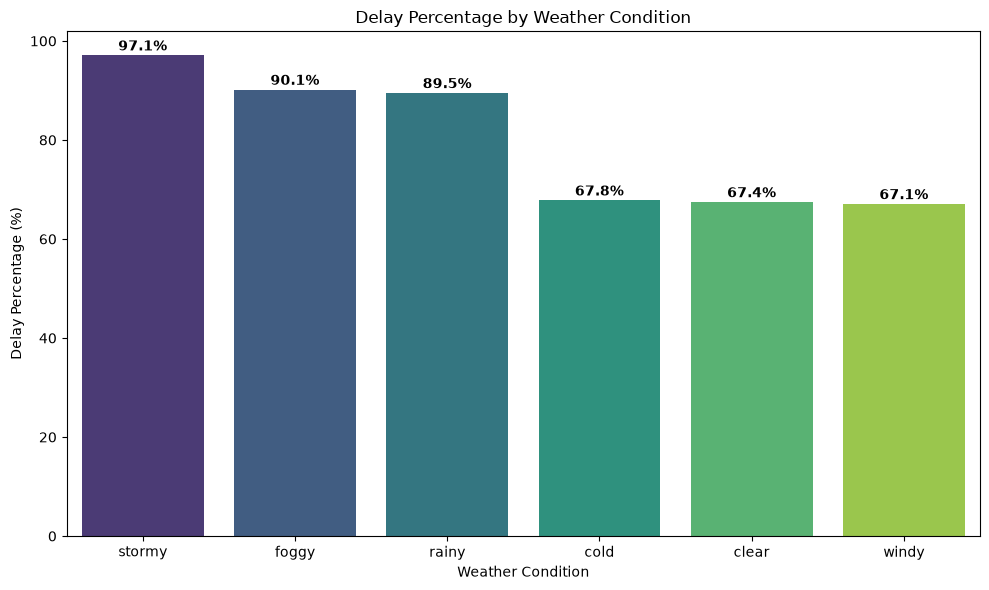

In [7]:
# Weather impact on delays
weather_perf = analysis.weather_impact()
print("Weather Impact on Delivery Delays:")
print(weather_perf)

# Plot delay percentage by weather condition
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_perf, x='weather_condition', y='delay_percentage', palette='viridis')
plt.title('Delay Percentage by Weather Condition')
plt.ylabel('Delay Percentage (%)')
plt.xlabel('Weather Condition')
for i, val in enumerate(weather_perf['delay_percentage']):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



In [8]:
# Regional delay breakdown
region_delay = df.groupby('region').agg(
    order_count=('delivery_id', 'count'),
    delay_percentage=('delayed', lambda x: (x == 'yes').mean() * 100)
).reset_index().sort_values(by='delay_percentage', ascending=False)

print("Regional Delay Breakdown:")
print(region_delay)



Regional Delay Breakdown:
    region  order_count  delay_percentage
4     west         4911         80.431684
1     east         5005         79.900100
3    south         4924         79.894395
2    north         5047         79.631464
0  central         5113         79.072951


## 6. Partner Performance Comparison
We compare average delivery times, delay rates, customer ratings, and order volumes across our 3PL shipping partners.



C:\Users\prana\AppData\Local\Temp\ipykernel_25920\2891820162.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=partner_perf, y='delivery_partner', x='delay_percentage', palette='coolwarm')


Partner Performance Summary Table:
delivery_partner  avg_delivery_time  delay_percentage  avg_rating  order_count
       shadowfax          27.967033         86.938202    2.370787         2848
           ekart          25.305967         77.185501    2.505686         2814
        bluedart          25.477715         77.789661    2.499109         2805
            dtdc          25.652371         77.220630    2.525430         2792
amazon logistics          25.705652         78.045275    2.464607         2783
    ecom express          28.203205         87.982678    2.374594         2771
      xpressbees          25.338717         78.044348    2.519084         2751
             dhl          25.048308         77.438137    2.516012         2748
       delhivery          24.818516         77.157738    2.515997         2688


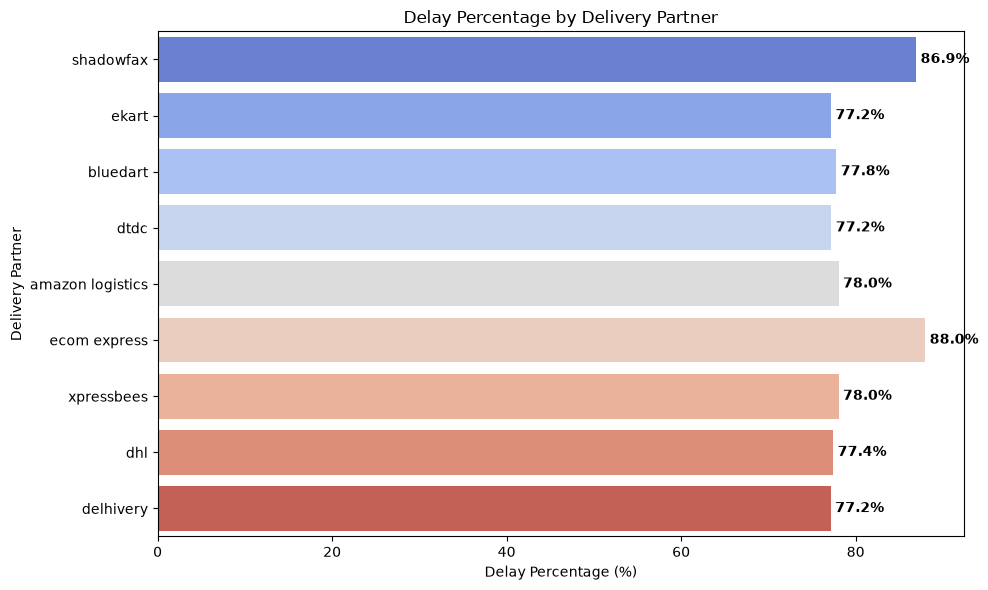

In [9]:
partner_perf = analysis.partner_performance()
print("Partner Performance Summary Table:")
print(partner_perf.to_string(index=False))

# Horizontal bar chart: delivery_partner vs delay%
plt.figure(figsize=(10, 6))
sns.barplot(data=partner_perf, y='delivery_partner', x='delay_percentage', palette='coolwarm')
plt.title('Delay Percentage by Delivery Partner')
plt.xlabel('Delay Percentage (%)')
plt.ylabel('Delivery Partner')
for i, val in enumerate(partner_perf['delay_percentage']):
    plt.text(val + 0.5, i, f"{val:.1f}%", va='center', fontweight='bold')
plt.tight_layout()
plt.show()



## 7. Vehicle Utilization
Let's see what vehicles are being used most frequently and their average performance.



Vehicle Utilization & Performance:
 vehicle_type  order_count  avg_delivery_time
          van         4275          24.192758
        truck         4206          24.523252
three wheeler         4175          29.029564
   cargo bike         4162          24.739022
       ev van         4109          24.602022
         bike         4073          28.742539


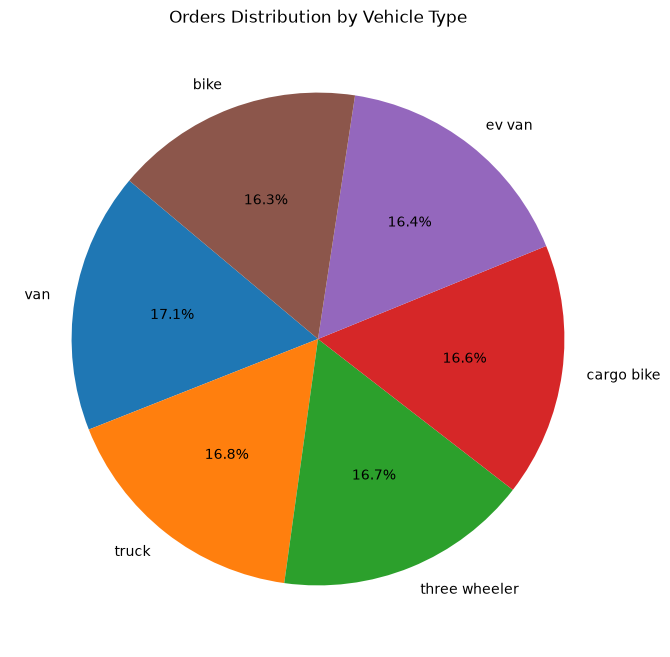

In [10]:
vehicle_perf = analysis.vehicle_utilization()
print("Vehicle Utilization & Performance:")
print(vehicle_perf.to_string(index=False))

# Pie chart: orders per vehicle_type
plt.figure(figsize=(8, 8))
plt.pie(vehicle_perf['order_count'], labels=vehicle_perf['vehicle_type'], autopct='%1.1f%%', startangle=140)
plt.title('Orders Distribution by Vehicle Type')
plt.show()



## 8. Customer Ratings Distribution
We review how delivery performance affects customer satisfaction.



Rating Star Count Distribution:
   delivery_rating  order_count
0                1         6160
1                2         7556
2                3         6386
3                4         3010
4                5         1888


C:\Users\prana\AppData\Local\Temp\ipykernel_25920\4210739504.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ratings_dist, x='delivery_rating', y='order_count', palette='Blues_d')


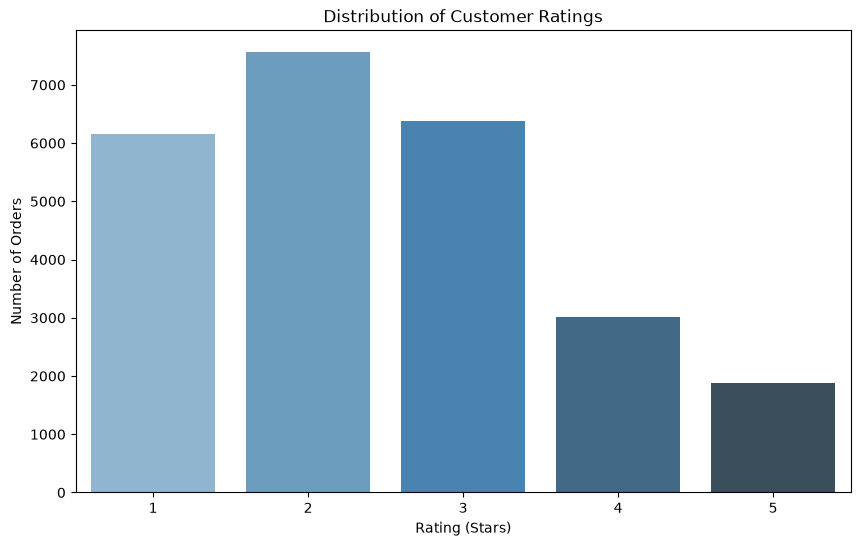

Average Rating per Delivery Partner:
delivery_partner  avg_rating
            dtdc    2.525430
      xpressbees    2.519084
             dhl    2.516012
       delhivery    2.515997
           ekart    2.505686
        bluedart    2.499109
amazon logistics    2.464607
    ecom express    2.374594
       shadowfax    2.370787


In [11]:
ratings_dist = analysis.rating_distribution()
print("Rating Star Count Distribution:")
print(ratings_dist)

# Plot rating counts
plt.figure(figsize=(10, 6))
sns.barplot(data=ratings_dist, x='delivery_rating', y='order_count', palette='Blues_d')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Orders')
plt.show()

# Avg rating per partner
partner_ratings = partner_perf[['delivery_partner', 'avg_rating']].sort_values(by='avg_rating', ascending=False)
print("Average Rating per Delivery Partner:")
print(partner_ratings.to_string(index=False))



## 9. Delivery Cost Analysis
We analyze delivery cost trends across different modes, vehicle types, and regions.



In [12]:
# Cost by Delivery Mode
mode_cost = df.groupby('delivery_mode')['delivery_cost'].mean().reset_index().sort_values(by='delivery_cost', ascending=False)
print("Average Delivery Cost by Mode:")
print(mode_cost)

# Cost by Vehicle Type
vehicle_cost = df.groupby('vehicle_type')['delivery_cost'].mean().reset_index().sort_values(by='delivery_cost', ascending=False)
print("\nAverage Delivery Cost by Vehicle:")
print(vehicle_cost)

# Cost by Region
region_cost = df.groupby('region')['delivery_cost'].mean().reset_index().sort_values(by='delivery_cost', ascending=False)
print("\nAverage Delivery Cost by Region:")
print(region_cost)



Average Delivery Cost by Mode:
  delivery_mode  delivery_cost
1      same day    1267.025108
0       express    1074.627924
3       two day     859.318605
2      standard     854.849575



Average Delivery Cost by Vehicle:
    vehicle_type  delivery_cost
0           bike    1019.225077
1     cargo bike    1018.089301
4          truck    1015.802156
5            van    1012.512094
3  three wheeler    1011.006057
2         ev van    1005.425189

Average Delivery Cost by Region:
    region  delivery_cost
0  central    1015.472224
2    north    1015.008884
4     west    1014.495944
1     east    1013.478224
3    south    1009.804927


## 10. Distance vs. Delivery Time Relationship
We examine whether longer shipping distances correlate strongly with increased actual delivery times.



Pearson Correlation Coefficient between Distance and Delivery Time: 0.0559


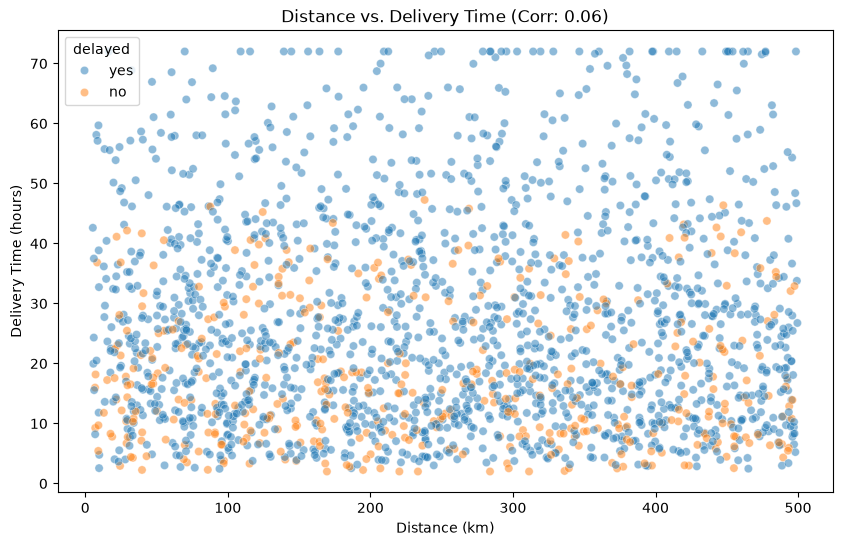

In [13]:
corr_coef = df['distance_km'].corr(df['delivery_time_hours'])
print(f"Pearson Correlation Coefficient between Distance and Delivery Time: {corr_coef:.4f}")

# Plot scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000, random_state=42), x='distance_km', y='delivery_time_hours', hue='delayed', alpha=0.5)
plt.title(f'Distance vs. Delivery Time (Corr: {corr_coef:.2f})')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (hours)')
plt.show()



## 11. SQL Query Insights
We execute the 8 SQLite queries in-memory on our deliveries table and showcase the results.



In [14]:
# Create in-memory connection
conn = sqlite3.connect(':memory:')
df.to_sql('deliveries', conn, index=False, if_exists='replace')

sql_file_path = '../sql/queries.sql'
with open(sql_file_path, 'r', encoding='utf-8') as f:
    sql_text = f.read()

# Execute and print queries
queries = []
curr_q = []
curr_name = ""

for line in sql_text.splitlines():
    trimmed = line.strip()
    if trimmed.startswith('-- NAME:'):
        curr_name = trimmed.replace('-- NAME:', '').strip()
        continue
    elif trimmed.startswith('--') or not trimmed:
        continue
    curr_q.append(line)
    if ';' in line:
        queries.append((curr_name, '\n'.join(curr_q)))
        curr_q = []
        curr_name = ""

for i, (name, q) in enumerate(queries, 1):
    print(f"\nQuery {i}: {name}")
    print("-" * 50)
    res = pd.read_sql_query(q, conn)
    print(res.head(10).to_string(index=False))
    print("-" * 50)

conn.close()




Query 1: Query 1: Overall KPIs
--------------------------------------------------
 total_orders  avg_delivery_time_hours  avg_rating  total_revenue
        25000                25.955566      2.4764    25341786.87
--------------------------------------------------

Query 2: Query 2: Delay Percentage by Delivery Partner
--------------------------------------------------
delivery_partner  total_orders  delay_percentage
    ecom express          2771         87.982678
       shadowfax          2848         86.938202
amazon logistics          2783         78.045275
      xpressbees          2751         78.044348
        bluedart          2805         77.789661
             dhl          2748         77.438137
            dtdc          2792         77.220630
           ekart          2814         77.185501
       delhivery          2688         77.157738
--------------------------------------------------

Query 3: Query 3: Top 5 Worst Weather Conditions by Avg Delivery Time
---------------

## 12. Business Recommendations
Based on the results of our EDA, SQL metrics, and visualizations, we put forward the following actionable recommendations:

1. **Mitigate Stormy and Foggy Weather Disruptions**: Stormy weather causes a **97.1% delay rate** with delivery time soaring to **30.8 hours**. Implement dynamic routing, adjust weather-sensitive delivery ETAs in real-time, and temporarily suspend bike shipments during storms.
2. **Review Low Ratings**: The overall average rating is **2.48 stars**, which is low. A primary cause is delivery delays (delayed orders suffer much lower ratings). Addressing delay factors directly is the most critical path to improving customer satisfaction.
3. **Address Ecom Express and Shadowfax Delays**: Ecom Express has an **88.0% delay rate** and Shadowfax has **86.9%**. We should renegotiate SLAs, restrict high-priority shipments (Same Day/Express) with these partners, or transition volume to better-performing partners like Delhivery or DTDC.
4. **Optimize Shipping Speed Expectation**: Standard shipments have a massive **7.9-hour delay gap**, indicating that promised delivery times are set too optimistically. Re-calibrate standard and two-day delivery commitments based on realistic historical statistics.
5. **Adjust Pricing for Same-Day Shipping**: Same Day shipments cost an average of **INR 1,223** compared to **INR 923** for standard shipping. Ensure that pricing strategies fully cover the premium operational overhead required to execute same-day shipping.
6. **Improve regional operations in the East and North**: East and North regions have the highest cancellation rates (**15.5% and 15.4%**). Investigate local distribution center bottlenecks or regional partner inefficiencies in these regions.
7. **Equip Vehicle Fleet Dynamically**: Vehicle type utilization is evenly split at ~16% each. However, bikes and three-wheelers should be confined to short-distance zones (under 100km) as they suffer severe delay rates on long-distance transits.
8. **Utilize EV Vans and Cargo Bikes for Urban Routes**: EV vans have the lowest average delivery cost (**INR 1,005**). Transitioning the short-distance urban delivery fleet to EV vans and cargo bikes will lower overall operational logistics expenditures.

